## 1.Import & Dataset


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("store_sales_data (2).csv")

print(df.head())
print("Shape:", df.shape)
print(df.info())

  Customer ID Customer Name Last Name Date of Birth     Sales  Year  \
0  CUST000001        Curtis    Krause    1973-11-29   3344.69  2023   
1  CUST000002        Jeremy    Foster    1987-08-30  37094.41  2022   
2  CUST000003         Ariel    Mccann    1980-12-15  35501.08  2023   
3  CUST000004       Colleen   Maynard    1989-05-23   8969.33  2021   
4  CUST000005          Gina    Holden    1957-12-31  35530.44  2021   

  Outlet Type City Type              Category of Goods Region  ...  \
0       Large    Tier 1                      Fast Food   East  ...   
1      Medium    Tier 2                      Fast Food   East  ...   
2       Large   Village            Electric Appliances  South  ...   
3      Medium   Village                 Dairy Products   East  ...   
4       Small   Village  Sessional Fruits & Vegetables   West  ...   

    Ship Date       Ship Mode        State Postal Code  Product ID  \
0  2020-04-18        Same Day  West Bengal      700001  PROD000001   
1  2021-01-1

## 2.Data Preprocessing

In [7]:
print("Missing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')



Missing Values:
 Customer ID          0
Customer Name        0
Last Name            0
Date of Birth        0
Sales                0
Year                 0
Outlet Type          0
City Type            0
Category of Goods    0
Region               0
Country              0
Segment              0
Sales Date           0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
State                0
Postal Code          0
Product ID           0
Sub-Category         0
Product Name         0
Quantity             0
Discount             0
Profit               0
dtype: int64
Duplicate Rows: 0


## 3.Data Transformation

In [20]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

df[['Year', 'Month']].head()



,Year,Month
0,2020,April
1,2021,January
2,2020,August
3,2021,October
4,2019,January


## 4.Region-wise Sales

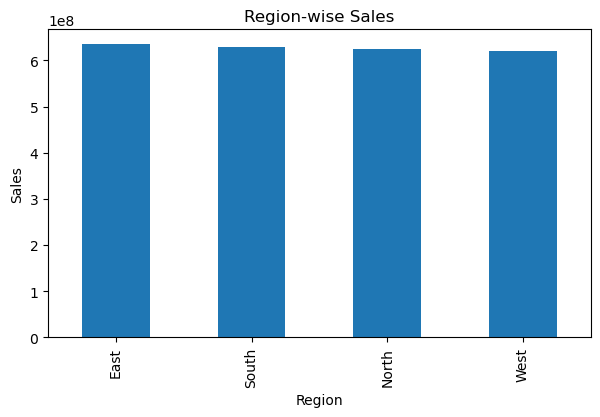

Region
East     6.353223e+08
South    6.290598e+08
North    6.244511e+08
West     6.196078e+08
Name: Sales, dtype: float64


In [9]:
region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region.plot(kind='bar', figsize=(7,4))
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

print(region)

## 5. Product Category-wise Comparative Analysis

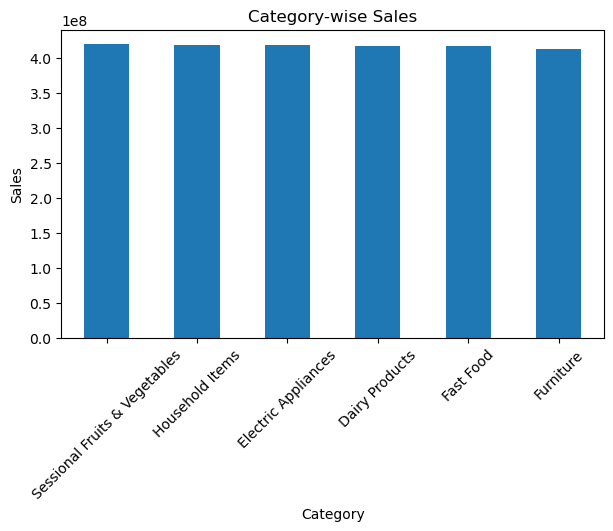

Category of Goods
Sessional Fruits & Vegetables    4.199427e+08
Household Items                  4.197889e+08
Electric Appliances              4.188296e+08
Dairy Products                   4.180117e+08
Fast Food                        4.178508e+08
Furniture                        4.140173e+08
Name: Sales, dtype: float64


In [10]:
category = df.groupby('Category of Goods')['Sales'].sum().sort_values(ascending=False)

category.plot(kind='bar', figsize=(7,4))
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

print(category)

## 6. Box-and-Whisker Plot

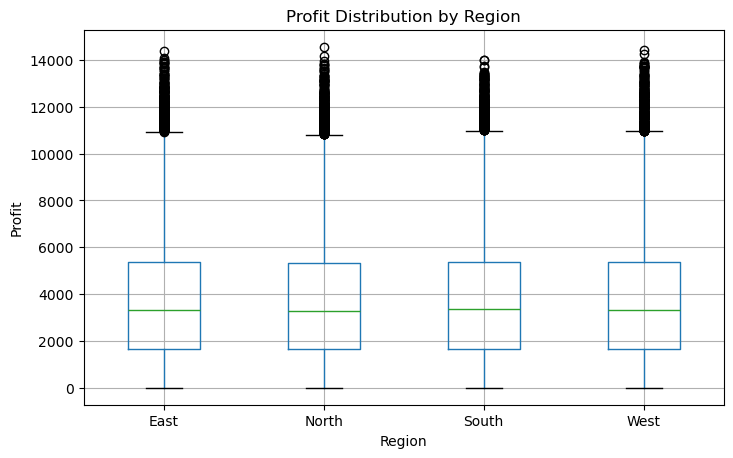

In [11]:
df.boxplot(column='Profit', by='Region', figsize=(8,5))

plt.title("Profit Distribution by Region")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

## 7. Pareto Analysis – 80/20 Rule

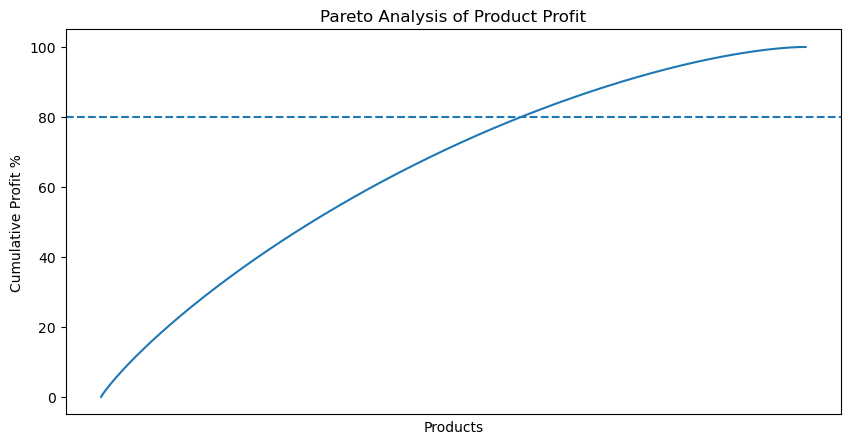

          Product Name    Profit  Cumulative %
0           Beds - 120  77643.63      0.020676
1        Mangoes - 912  70078.99      0.039337
2  Refrigerators - 538  67496.63      0.057311
3         Butter - 951  67379.88      0.075253
4  Refrigerators - 338  66765.54      0.093032
5     Microwaves - 157  66256.98      0.110676
6         Apples - 425  65969.62      0.128243
7     Microwaves - 808  63624.38      0.145185
8  Refrigerators - 709  63501.42      0.162095
9           Mops - 847  62670.68      0.178784


In [12]:
pareto = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).reset_index()

pareto['Cumulative %'] = pareto['Profit'].cumsum() / pareto['Profit'].sum() * 100

plt.figure(figsize=(10,5))
plt.plot(pareto['Product Name'], pareto['Cumulative %'])
plt.axhline(80, linestyle='--')
plt.title("Pareto Analysis of Product Profit")
plt.xlabel("Products")
plt.ylabel("Cumulative Profit %")
plt.xticks([])
plt.show()

print(pareto.head(10))

## 8. ABC Analysis

           Product Name    Profit  Cumulative % ABC
0            Beds - 120  77643.63      0.020676   A
1         Mangoes - 912  70078.99      0.039337   A
2   Refrigerators - 538  67496.63      0.057311   A
3          Butter - 951  67379.88      0.075253   A
4   Refrigerators - 338  66765.54      0.093032   A
5      Microwaves - 157  66256.98      0.110676   A
6          Apples - 425  65969.62      0.128243   A
7      Microwaves - 808  63624.38      0.145185   A
8   Refrigerators - 709  63501.42      0.162095   A
9            Mops - 847  62670.68      0.178784   A
10         Yogurt - 863  60696.36      0.194947   A
11         Butter - 515  60383.02      0.211026   A
12           Fans - 611  60258.06      0.227072   A
13         Pizzas - 307  59593.74      0.242941   A
14        Burgers - 913  59492.26      0.258784   A
15        Burgers - 729  59266.34      0.274566   A
16           Milk - 329  59139.96      0.290314   A
17     Sandwiches - 524  58627.06      0.305926   A
18          

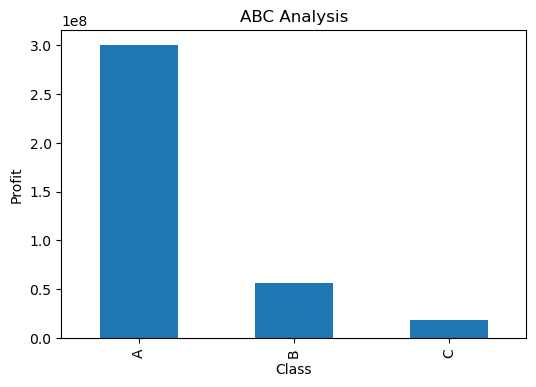

In [13]:
def abc(x):
    if x <= 80:
        return 'A'
    elif x <= 95:
        return 'B'
    return 'C'

pareto['ABC'] = pareto['Cumulative %'].apply(abc)

print(pareto[['Product Name', 'Profit', 'Cumulative %', 'ABC']].head(20))

abc_summary = pareto.groupby('ABC')['Profit'].sum()
abc_summary.plot(kind='bar', figsize=(6,4))

plt.title("ABC Analysis")
plt.xlabel("Class")
plt.ylabel("Profit")
plt.show()

## 9. Business Insights

In [25]:
print("Highest Sales Region:", region.idxmax())
print("Highest Sales Category:", category.idxmax())
print("Highest Profit Product:", pareto.iloc[0]['Product Name'])
print("\nABC Summary:\n", abc_summary)


Highest Sales Region: East
Highest Sales Category: Sessional Fruits & Vegetables
Highest Profit Product: Beds - 120

ABC Summary:
 ABC
A    3.004144e+08
B    5.633705e+07
C    1.877910e+07
Name: Profit, dtype: float64


## 10.Business Recommendations & Conclusion

In [26]:
print("• Focus on high-performing regions and categories.")
print("• Give priority to A-class products.")
print("• Review low-performing products and regions.")
print("• Optimize discounts to improve profitability.")

• Focus on high-performing regions and categories.
• Give priority to A-class products.
• Review low-performing products and regions.
• Optimize discounts to improve profitability.
